In [193]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [194]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [195]:

# Value class with data, grad, _backward, _prev, _op
#  __add__ with _backward closure (gradient flows equally to both parents)
#  __mul__ with _backward (chain rule: each parent gets the other's data × out.grad)
#  __pow__ for scalar exponents
#  __neg__, __sub__, __truediv__, __radd__, __rmul__ (reverse ops for 2 * x)
#  tanh() method with _backward (derivative: 1 - tanh²)
class Value:
    def __init__(self, data, _children=(), op='', _label = ''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = op
        self.grad = 0.0
        self._label = _label

    def __repr__(self):
        return f"Value data={self.data}"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        new_value = Value(self.data + other.data, (self, other), "+")
        
        def _backward():
            self.grad += new_value.grad * 1
            other.grad += new_value.grad * 1
        
        new_value._backward = _backward
        return new_value

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        new_value = Value(self.data * other.data, (self, other), "*")
        
        def _backward():
            self.grad += new_value.grad * other.data
            other.grad += new_value.grad * self.data
        
        new_value._backward = _backward
        return new_value
    
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    
    def __pow__(self, power):
        new_value = Value(self.data ** power, (self,), _label=f"^{power}")

        def _backward():
            self.grad += (power)*self.data**(power-1)*new_value.grad

        new_value._backward = _backward
        return new_value
    
    
    def __neg__(self):
        return self * (-1)        # done. __mul__ handles the gradient, after this, -x is defined
    
    def __sub__(self, other): 
        return self + (-other)
    
    def __rsub__(self, other):   # other - self
        return (-self) + other
    
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    
    # Tanh
    def tanh(self): 
        new_value = Value((math.exp(self.data*2)-1) / (math.exp(self.data*2) +1), (self,), "tanh")

        def _backward():
            self.grad += (1 - new_value.data**2) * new_value.grad # chain

        new_value._backward = _backward
        return new_value

    # Sigmoid
    def sigmoid(self):
        s = 1 / (math.exp(-self.data) + 1)
        new_value = Value(s, (self,), 'sigmoid')
        def _backward():
            self.grad += s * (1 - s) * new_value.grad
        
        new_value._backward = _backward
        return new_value
    
    # Using for Binary Cross-Entropy: -[y*log(yh) + (1-y)log(1-yh)]
    def log(self):
        new_value = Value(math.log(self.data + 1e-12), (self, ), "log")
        def _backward():
            self.grad += (1 / (self.data + 1e-12)) * new_value.grad # <---- 1e-12 for log(0) collision

        new_value._backward = _backward
        return new_value
            
    def backward(self):
        self.grad = 1
        topoList = _build_topo(self)
        for val in reversed(topoList):
            val._backward()

def _build_topo(val):
    topo = []
    visited = set()

    def _build_topo(val):
        if val not in visited:
            visited.add(val)
            for child in val._prev:
                _build_topo(child)
            topo.append(val)
    
    _build_topo(val)

    return topo

In [197]:

class Neuron: 
    # input unit = scalar
    # output unit = scalar
    def __init__(self, index, n_input, n_output, activation = 'tanh'):
        p = self.xavier_uniform(n_input, n_output)
        local_weight = []
        for _ in range(n_input):
            local_weight.append(Value(random.uniform(-p, p)))

        self.w = local_weight
        self.b = Value(0.0, _label=f"L1_b{index}")
        self.activation = activation
        self.n_input = n_input
    
    def xavier_uniform(self, n_input, n_output):
        return math.sqrt(6 / (n_input + n_output))
    
    def parameters(self):
    #    print("weights: ", self.w, " -- total length: ", len(self.w) + 1)
       return self.w + [self.b] # wrap both into a singlelist, which b will serve as the bias within that list.

    def __call__(self, input_features):
        result = 0
        for i in range(self.n_input):
            result += self.w[i] * input_features[i]
        
        result += self.b

        # activation
        if (self.activation == 'tanh'):
            activated = result.tanh()
        elif (self.activation == 'sigmoid'):
            activated = result.sigmoid()

        return activated
    
class Layer:
    def __init__(self, n_input, n_output, activation = 'tanh'):
        neurons = []
        for i in range(n_output):
            neurons.append(Neuron(index=i, n_input=n_input, n_output=n_output, activation=activation))
        self.n_input = n_input
        self.n_output = n_output
        self.result = []
        self.neurons = neurons

    def __call__(self, input_feature):
        result = []
        for i in range(self.n_output):
            activation_result = self.neurons[i](input_feature)
            result.append(activation_result)
        
        # return 1 value when only 1 is return
        return result[0] if len(result) == 1 else result 

    def parameters(self):
        flatten_params = []
        for val in self.neurons:
            res = val.parameters()
            flatten_params += res
        
        # print("+++++++++ total: ", len(flatten_params), " ++++++++++++++")
        return flatten_params
    
class MultilayerPerceptron:
    # MLP(n_input=30, layer_sizes=[16, 1])
    def __init__(self, n_input, layer_sizes, activations):
        size = [n_input] + layer_sizes
        layers = []
        for i in range (len(size)):
            if i == len(size) - 1:
                break
            layers.append(Layer(n_input=size[i], n_output=size[i+1], activation=activations[i]))
        
        self.layers = layers
        self.layer_sizes = layer_sizes
    
    def parameters(self):
        params = []
        for val in self.layers:
            params += val.parameters()

        return params

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def __call__(self, input_feature):
        layer_result = input_feature
        for layer in self.layers:
            tempt = layer(layer_result)
            layer_result = tempt
        
        return layer_result



In [198]:
random.seed(42)
model = MultilayerPerceptron(30, [16, 1], ['tanh', 'sigmoid'])

print(len(model.parameters()))
assert len(model.parameters()) == 513
x = [Value(random.uniform(-1, 1)) for _ in range(30)]
out = model(x)
assert isinstance(out, Value), f"got {type(out)} — Layer didn't collapse to single Value"
assert 0 < out.data < 1
out.backward()
model.zero_grad()
assert all(p.grad == 0.0 for p in model.parameters())
print("✅ all checks pass")

513
✅ all checks pass


In [199]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

# Convert to Value objects ONCE upfront — don't rewrap every epoch
X_tr_v = [[Value(float(v)) for v in row] for row in X_tr]
X_te_v = [[Value(float(v)) for v in row] for row in X_te]



In [201]:
# Sanity test: when ŷ = y, loss should be near 0
y_pred = Value(0.99)
loss = bce_loss(y_pred, 1.0)
print(loss.data)
print(f"ŷ=0.99, y=1: loss = {loss.data:.4f}")    # expect ~0.01

y_pred = Value(0.01)
loss = bce_loss(y_pred, 0.0)
print(loss)
print(f"ŷ=0.01, y=0: loss = {loss.data:.4f}")    # expect ~0.01

# Sanity test: when ŷ is wrong, loss should be large
y_pred = Value(0.01)
loss = bce_loss(y_pred, 1.0)
print(loss)
print(f"ŷ=0.01, y=1: loss = {loss.data:.4f}")    # expect ~4.6

# Backward sanity: gradient should match (ŷ - y) on the pre-sigmoid logit
# (test this once you wire it up to a full forward pass)

0.010050335852491371
ŷ=0.99, y=1: loss = 0.0101
Value data=0.010050335852491371
ŷ=0.01, y=0: loss = 0.0101
Value data=4.605170185888091
ŷ=0.01, y=1: loss = 4.6052


In [200]:
def bce_loss(y_pred: Value, y_true):
    """
    y_pred: a Value (sigmoid output, in (0,1))
    y_true: a Python float, 0.0 or 1.0
    Returns: a Value representing -[y log(ŷ) + (1-y) log(1-ŷ)]
    """
    return (y_true * y_pred.log() + (1 - y_true) * (1 - y_pred).log())*(-1)

In [202]:
import pickle
import os

ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


def save_model(model, path):
    """Save model architecture + learned parameter values."""
    state = {
        'n_input': len(model.layers[0].neurons[0].w),
        'layer_sizes': [layer.n_output for layer in model.layers],
        'activations': [layer.neurons[0].activation for layer in model.layers],
        'params': [p.data for p in model.parameters()],
    }
    with open(path, 'wb') as f:
        pickle.dump(state, f)
    print(f"💾 model saved to {path}")


def load_model(path):
    """Reconstruct model and load trained weights."""
    with open(path, 'rb') as f:
        state = pickle.load(f)
    model = MultilayerPerceptron(
        n_input=state['n_input'],
        layer_sizes=state['layer_sizes'],
        activations=state['activations'],
    )
    for p, value in zip(model.parameters(), state['params']):
        p.data = value
    print(f"📂 model loaded from {path}")
    return model


def save_scaler(scaler, path):
    with open(path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"💾 scaler saved to {path}")


def load_scaler(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

In [203]:
import os
ARTIFACTS_DIR = 'artifacts'
ASSETS_DIR = 'assets'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(ASSETS_DIR, exist_ok=True)


mean loss on epoch:  0 : ... Value data=1.0725279230022924
mean loss on epoch:  10 : ... Value data=0.4077538277420128
mean loss on epoch:  20 : ... Value data=0.2733632622909679
mean loss on epoch:  30 : ... Value data=0.2176428536378352
mean loss on epoch:  40 : ... Value data=0.1861958756807291
mean loss on epoch:  50 : ... Value data=0.16546314590475067
mean loss on epoch:  60 : ... Value data=0.15051214039258498
mean loss on epoch:  70 : ... Value data=0.13908948630761567
mean loss on epoch:  80 : ... Value data=0.1300020860034349
mean loss on epoch:  90 : ... Value data=0.12255282396511695
mean loss on epoch:  100 : ... Value data=0.11630483630144876
💾 model saved to artifacts/model.pkl
💾 scaler saved to artifacts/scaler.pkl


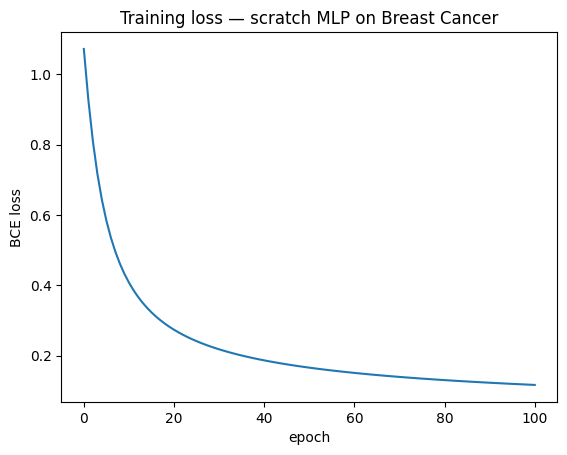

In [205]:
def train():
    losses = []
    epochs = 101
    learning_rate = 0.05
    model = MultilayerPerceptron(30, [16, 1], ['tanh', 'sigmoid'])

    for epoch in range(epochs):
        model.zero_grad()
        total_loss = Value(0.0)

        for x, y in zip(X_tr_v, y_tr):
            y_pred = model(x)
            loss = bce_loss(y_pred, float(y))
            total_loss = total_loss + loss
        
        mean_loss = total_loss * (1.0 / len(X_tr_v))
        mean_loss.backward()

        for p in model.parameters():
            p.data -= learning_rate * p.grad
        
        losses.append(mean_loss.data)
        if epoch % 10 == 0:
            # evaluate accuracy on X_te
            print("mean loss on epoch: ", epoch, ": ...", mean_loss)

    
    plt.plot(losses); plt.xlabel('epoch'); plt.ylabel('BCE loss')
    plt.title('Training loss — scratch MLP on Breast Cancer')
    plt.savefig('assets/loss_curve.png', dpi=120, bbox_inches='tight')

    # === save artifacts ===
    save_model(model, f'{ARTIFACTS_DIR}/model.pkl')
    save_scaler(scaler, f'{ARTIFACTS_DIR}/scaler.pkl')


train()

In [206]:
def accuracy(model, X_v, y):
    correct = 0
    for x, true_y in zip(X_v, y):
        prob = model(x).data
        pred = 1 if prob >= 0.5 else 0
        actual = int(true_y)
        if pred == actual:
            correct += 1
    return correct / len(y)

In [209]:
model_loaded = load_model(f'{ARTIFACTS_DIR}/model.pkl')
print(f"Train acc: {accuracy(model_loaded, X_tr_v, y_tr):.4f}")
print(f"Test  acc: {accuracy(model_loaded, X_te_v, y_te):.4f}")


📂 model loaded from artifacts/model.pkl
Train acc: 0.9648
Test  acc: 0.9561


In [ ]:
def gradient_check(model, x, y_true, n_checks=10, eps=1e-5):
    """
    Verify analytical gradients (from autograd) match numerical gradients.
    Uses a single sample to keep it tractable.
    """
    # 1. Forward + backward to get analytical grads
    model.zero_grad()
    y_pred = model(x)
    loss = bce_loss(y_pred, y_true)
    loss.backward()
    
    params = model.parameters()
    # Snapshot analytical grads (they'll be overwritten when we re-forward)
    analytical = [p.grad for p in params]
    
    # 2. Pick n_checks random params, compute numerical grad
    import random
    indices = random.sample(range(len(params)), n_checks)
    
    print(f"{'idx':>5} {'analytical':>14} {'numerical':>14} {'rel_error':>12}  ok?")
    print('-' * 60)
    
    all_ok = True
    for idx in indices:
        p = params[idx]
        orig = p.data
        
        # L(w + eps)
        p.data = orig + eps
        loss_plus = bce_loss(model(x), y_true).data
        
        # L(w - eps)
        p.data = orig - eps
        loss_minus = bce_loss(model(x), y_true).data
        
        # restore
        p.data = orig
        
        numerical = (loss_plus - loss_minus) / (2 * eps)
        a = analytical[idx]
        rel_err = abs(a - numerical) / (abs(a) + abs(numerical) + 1e-12)
        ok = rel_err < 1e-4
        all_ok = all_ok and ok
        
        print(f"{idx:>5} {a:>14.8f} {numerical:>14.8f} {rel_err:>12.2e}  {'✅' if ok else '❌'}")
    
    print('-' * 60)
    print('✅ ALL PASS' if all_ok else '❌ SOME FAILED — your backward is wrong')



In [211]:
random.seed(0)
test_model = MultilayerPerceptron(30, [16, 1], ['tanh', 'sigmoid'])
gradient_check(test_model, X_tr_v[0], float(y_tr[0]))

  idx     analytical      numerical    rel_error  ok?
------------------------------------------------------------
  258     0.10914758     0.10914758     5.33e-11  ✅
   80    -0.00260223    -0.00260223     3.28e-10  ✅
  360    -0.01013186    -0.01013186     6.65e-12  ✅
   72    -0.00310053    -0.00310053     1.13e-09  ✅
  124     0.29320084     0.29320084     1.76e-11  ✅
  367    -0.02548470    -0.02548470     1.41e-10  ✅
   30     0.02858372     0.02858372     8.83e-11  ✅
  353    -0.01757128    -0.01757128     2.64e-10  ✅
  356    -0.02341989    -0.02341990     5.63e-11  ✅
  182     0.30254190     0.30254190     1.53e-11  ✅
------------------------------------------------------------
✅ ALL PASS


In [ ]:
def predict(raw_features, model, scaler):
    """raw_features: array-like of 30 raw feature values"""
    x_scaled = scaler.transform([raw_features])[0]
    x_v = [Value(float(v)) for v in x_scaled]
    prob = model(x_v).data
    label = 'benign' if prob >= 0.5 else 'malignant'
    return prob, label


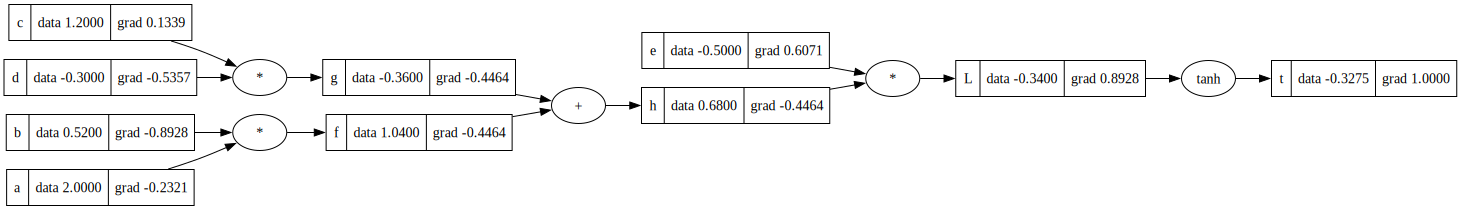

In [196]:
def forward_pass():
    # forward 
    a = Value(2, _label='a')
    b = Value(0.52, _label='b')
    c = Value(1.2, _label='c')
    d = Value(-0.3, _label='d')
    e = Value(-0.5, _label='e')

    f = a * b
    f._label="f"

    g = c * d
    g._label="g"

    h = f + g
    h._label="h"

    L = h * e
    L._label="L"

    t = L.tanh(); t._label = "t"
    return t

out = forward_pass()
out.backward()
draw_dot(out)

In [191]:
# Check what the model is predicting vs ground truth
import collections

preds = []
for x in X_te_v:
    preds.append(1 if model(x).data >= 0.5 else 0)

print("Prediction distribution:", collections.Counter(preds))
print("True distribution:      ", collections.Counter(int(y) for y in y_te))

# Show first 10 predictions vs truth
for i in range(10):
    p = model(X_te_v[i]).data
    print(f"  prob={p:.4f}  pred={1 if p >= 0.5 else 0}  true={int(y_te[i])}")

Prediction distribution: Counter({1: 65, 0: 49})
True distribution:       Counter({1: 72, 0: 42})
  prob=0.4255  pred=0  true=0
  prob=0.5784  pred=1  true=1
  prob=0.4688  pred=0  true=0
  prob=0.4096  pred=0  true=1
  prob=0.3425  pred=0  true=0
  prob=0.5476  pred=1  true=1
  prob=0.6306  pred=1  true=1
  prob=0.3719  pred=0  true=0
  prob=0.3340  pred=0  true=0
  prob=0.3754  pred=0  true=0


In [111]:
# forward 
a = Value(2, _label='a')
b = Value(0.52, _label='b')
c = Value(1.2, _label='c')
d = Value(-0.3, _label='d')
e = Value(-0.5, _label='e')

f = a * b
f._label="f"

g = c * d
g._label="g"

h = f + g
h._label="h"

L = h * e
L._label="L"

t = L.tanh(); t._label = "t"

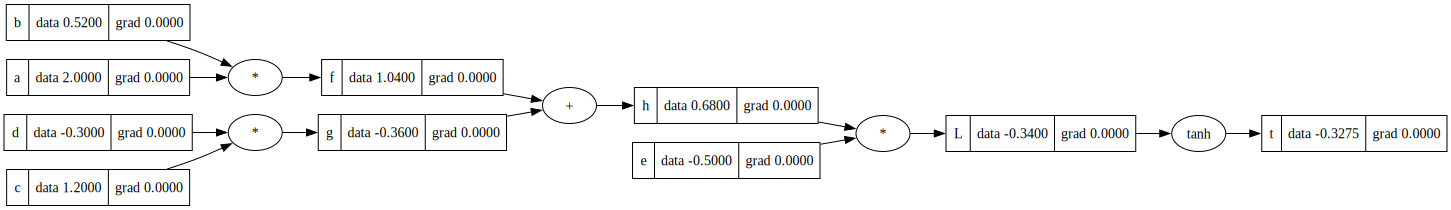

In [112]:
draw_dot(t)

In [ ]:
t.grad = 1
t._backward()

# grad_e = dL/de = h
# dL / de = h
L._backward()

# # e does not have _backward

# f, g
# grad f = dL/df = dL/dh * dh/df = 5 * (f + g)' = 5 * 1 = 5. => add is just copy the previous grad
h._backward()

# a, b
# grad a = dL/da = dL/dh * dh/df * df/da = -5 * b = -15
f._backward()
g._backward()


In [61]:
def gradchecking():
    # forward 
    a = Value(2, _label='a')
    b = Value(3, _label='b')
    c = Value(5, _label='c')
    d = Value(-2, _label='d')
    e = Value(-5, _label='e')

    f = a * b
    f._label="f"

    g = c * d
    g._label="g"

    h = f + g
    h._label="h"

    L1 = h * e
    L1._label="L"

    ee = Value(0.001)

    L2 = h * (e + ee)
    L2._label="L2"

    dd = (L2.data - L1.data) / ee.data
    print(dd)


gradchecking()

-4.000000000001336
